# TWI Assignment

### Get data from workbook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bb = pd.read_excel('/Users/jlaw/projects/stern/systematic-investing/data/assignment_basic_balance_data.xlsx', sheet_name='Basic Balance').rename(
    columns={
        'Unnamed: 0': 'Date',
        'Ln(TWI)': 'LnTWI',
        'Basic Balance ': 'BasicBalance',
    }
)

bb['Date'] = pd.to_datetime(bb['Date'])
for col in ['TWI', 'LnTWI', 'BasicBalance']:
    bb[col] = pd.to_numeric(bb[col], errors='coerce')

### Setup df with cols we need

In [2]:
df=bb[['Date','TWI','LnTWI','BasicBalance']]
df['TWI_ret'] = df['TWI'].pct_change().shift(-1) # shift next month's return up onto current row
df = df.dropna().reset_index(drop=True)
df.head()

,Date,TWI,LnTWI,BasicBalance,TWI_ret
0,1994-05-01,88.070503,4.478138,-116.837,-0.009662
1,1994-06-01,87.219607,4.468429,-107.294,-0.023313
2,1994-07-01,85.186222,4.444840,-93.934,0.002699
3,1994-08-01,85.416171,4.447535,-84.428,-0.011965
4,1994-09-01,84.394202,4.435499,-76.910,-0.010014


### Run strategy

In [3]:
C = 0.000871
A = 4.54
def twi_predicted(df, lag, threshold=0.0):
    df[f'pred_{lag}m_{threshold}lag_LnTWI'] = C * df['BasicBalance'].shift(lag) + A
    df[f'{lag}m_{threshold}lag_diff'] = df[f'pred_{lag}m_{threshold}lag_LnTWI'] - df['LnTWI']
    signal = np.where(df[f'{lag}m_{threshold}lag_diff'] > threshold, 1, #else:
             np.where(df[f'{lag}m_{threshold}lag_diff'] < -threshold, -1, 0))
    df[f'{lag}m_{threshold}lag_signal'] = pd.Series(signal, index=df.index, dtype='float64')
    df[f'{lag}m_{threshold}lag_ret'] = df[f'{lag}m_{threshold}lag_signal'] * df['TWI_ret']
    df[f'{lag}m_{threshold}lag_cumulative_ret'] = (1 + df[f'{lag}m_{threshold}lag_ret'].fillna(0)).cumprod()
    

In [4]:
for lag in range(1,7):
    twi_predicted(df, lag)

df.head(20)

,Date,TWI,LnTWI,BasicBalance,TWI_ret,pred_1m_0.0lag_LnTWI,1m_0.0lag_diff,1m_0.0lag_signal,1m_0.0lag_ret,1m_0.0lag_cumulative_ret,...,pred_5m_0.0lag_LnTWI,5m_0.0lag_diff,5m_0.0lag_signal,5m_0.0lag_ret,5m_0.0lag_cumulative_ret,pred_6m_0.0lag_LnTWI,6m_0.0lag_diff,6m_0.0lag_signal,6m_0.0lag_ret,6m_0.0lag_cumulative_ret
0,1994-05-01,88.070503,4.478138,-116.837,-0.009662,NaN,NaN,0.0,-0.000000,1.000000,...,NaN,NaN,0.0,-0.000000,1.000000,NaN,NaN,0.0,-0.000000,1.000000
1,1994-06-01,87.219607,4.468429,-107.294,-0.023313,4.438235,-0.030194,-1.0,0.023313,1.023313,...,NaN,NaN,0.0,-0.000000,1.000000,NaN,NaN,0.0,-0.000000,1.000000
2,1994-07-01,85.186222,4.444840,-93.934,0.002699,4.446547,0.001707,1.0,0.002699,1.026076,...,NaN,NaN,0.0,0.000000,1.000000,NaN,NaN,0.0,0.000000,1.000000
3,1994-08-01,85.416171,4.447535,-84.428,-0.011965,4.458183,0.010648,1.0,-0.011965,1.013799,...,NaN,NaN,0.0,-0.000000,1.000000,NaN,NaN,0.0,-0.000000,1.000000
4,1994-09-01,84.394202,4.435499,-76.910,-0.010014,4.466463,0.030965,1.0,-0.010014,1.003647,...,NaN,NaN,0.0,-0.000000,1.000000,NaN,NaN,0.0,-0.000000,1.000000
5,1994-10-01,83.549117,4.425435,-87.672,0.010543,4.473011,0.047577,1.0,0.010543,1.014229,...,4.438235,0.012800,1.0,0.010543,1.010543,NaN,NaN,0.0,0.000000,1.000000
6,1994-11-01,84.429999,4.435923,-93.301,0.018239,4.463638,0.027715,1.0,0.018239,1.032728,...,4.446547,0.010624,1.0,0.018239,1.028975,4.438235,0.002312,1.0,0.018239,1.018239
7,1994-12-01,85.969922,4.453997,-94.240,-0.004039,4.458735,0.004737,1.0,-0.004039,1.028557,...,4.458183,0.004186,1.0,-0.004039,1.024819,4.446547,-0.007451,-1.0,0.004039,1.022351
8,1995-01-01,85.622733,4.449951,-88.385,-0.010512,4.457917,0.007966,1.0,-0.010512,1.017745,...,4.466463,0.016512,1.0,-0.010512,1.014047,4.458183,0.008233,1.0,-0.010512,1.011605
9,1995-02-01,84.722708,4.439384,-82.284,-0.032484,4.463017,0.023633,1.0,-0.032484,0.984685,...,4.473011,0.033628,1.0,-0.032484,0.981107,4.466463,0.027080,1.0,-0.032484,0.978744


### Evaluate strategy

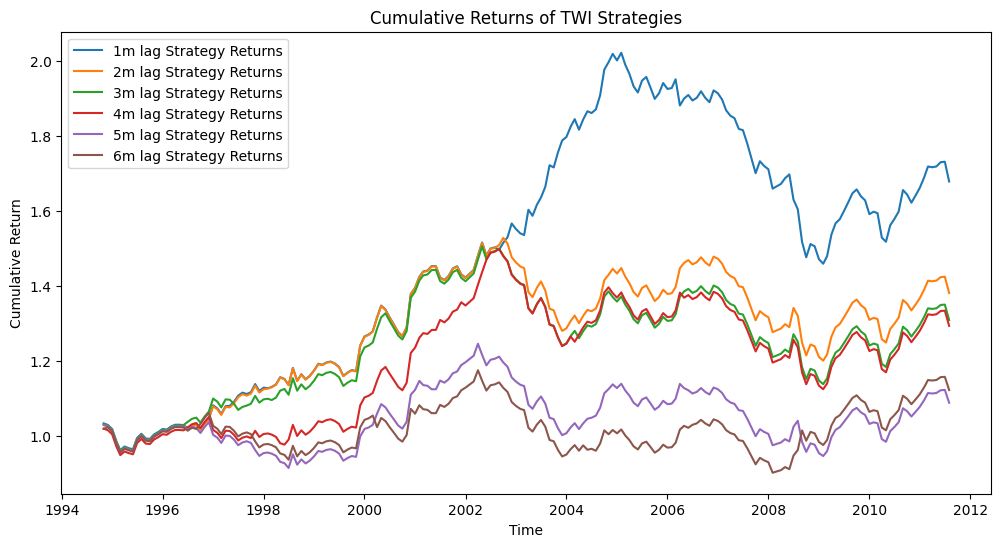

In [5]:
df = df.dropna().reset_index(drop=True)

plt.figure(figsize=(12, 6))
for lag in range(1,7):
    plt.plot(df['Date'], df[f'{lag}m_0.0lag_cumulative_ret'], label=f'{lag}m lag Strategy Returns')
plt.title('Cumulative Returns of TWI Strategies')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [6]:
for lag in range(1,7):
    print(f'{lag}m lag Sharpe: ', np.sqrt(12) * df[f'{lag}m_0.0lag_ret'].mean() / df[f'{lag}m_0.0lag_ret'].std())

1m lag Sharpe:  0.5368790681124361
2m lag Sharpe:  0.3425696236330084
3m lag Sharpe:  0.2858328545289872
4m lag Sharpe:  0.28572520824341663
5m lag Sharpe:  0.10295709215849183
6m lag Sharpe:  0.14390429333266225


## We see that the 1-month lag has the best cumulative returns and the strongest Sharpe, but it is not tradeable
## The strongest tradeable strategy is the 2-month lag TWI strategy, which has the second best cumulative returns and Sharpe ratio

### Sensitivity Analysis: 2-month lag

In [7]:
for lag in range(1,7):
    for threshold in {0.0, 0.01, 0.02, 0.03, 0.04, 0.05}:
        twi_predicted(df, lag, threshold)
    
    df = df.copy() # solves pandas memory management issue

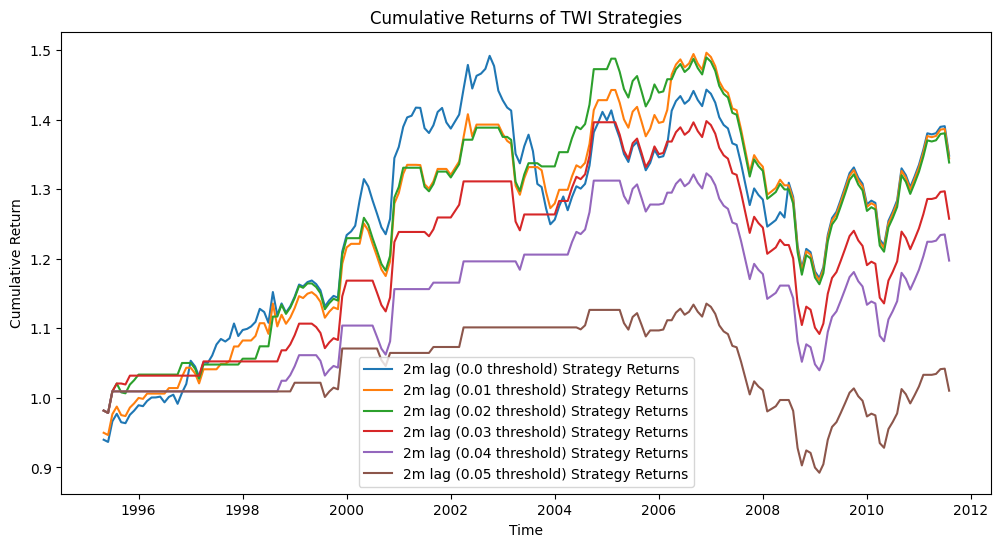

In [8]:
df = df.dropna().reset_index(drop=True)

plt.figure(figsize=(12, 6))
for threshold in [0.00, 0.01, 0.02, 0.03, 0.04, 0.05]:
    plt.plot(df['Date'], df[f'2m_{threshold}lag_cumulative_ret'], label=f'2m lag ({threshold} threshold) Strategy Returns')
plt.title('Cumulative Returns of TWI Strategies')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [9]:
for threshold in [0.00, 0.01, 0.02, 0.03, 0.04, 0.05]:
    print(f'{lag}m lag ({threshold} threshold) Sharpe: ', np.sqrt(12) * df[f'2m_{threshold}lag_ret'].mean() / df[f'2m_{threshold}lag_ret'].std())

6m lag (0.0 threshold) Sharpe:  0.39889184815117984
6m lag (0.01 threshold) Sharpe:  0.4102955328905876
6m lag (0.02 threshold) Sharpe:  0.38657801090974714
6m lag (0.03 threshold) Sharpe:  0.3293900644343142
6m lag (0.04 threshold) Sharpe:  0.2803483485949288
6m lag (0.05 threshold) Sharpe:  0.05671436920919702


## A threshold of 0.01 exhibits optimal performance: highest Sharpe ratio and among the strongest cumulative returns
## followed by 0.0 and 0.02 thresholds which have similarly strong cumulative returns and have closely trailing Sharpe ratios